EXERCICIO 1 - Portadora e Sinal Modulante

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fc = 10_000       # frequência da portadora (Hz)
fm = 500          # frequência do tom modulante (Hz)
fs = 200_000      # frequência de amostragem (Hz)
T  = 0.01         # duração do sinal (s)
t  = np.arange(0, T, 1/fs)

In [3]:
Ac, Am = 1.0, 1.0
c = Ac * np.cos(2*np.pi*fc*t)
m = Am * np.cos(2*np.pi*fm*t)

Text(0.5, 0, 'tempo(s)')

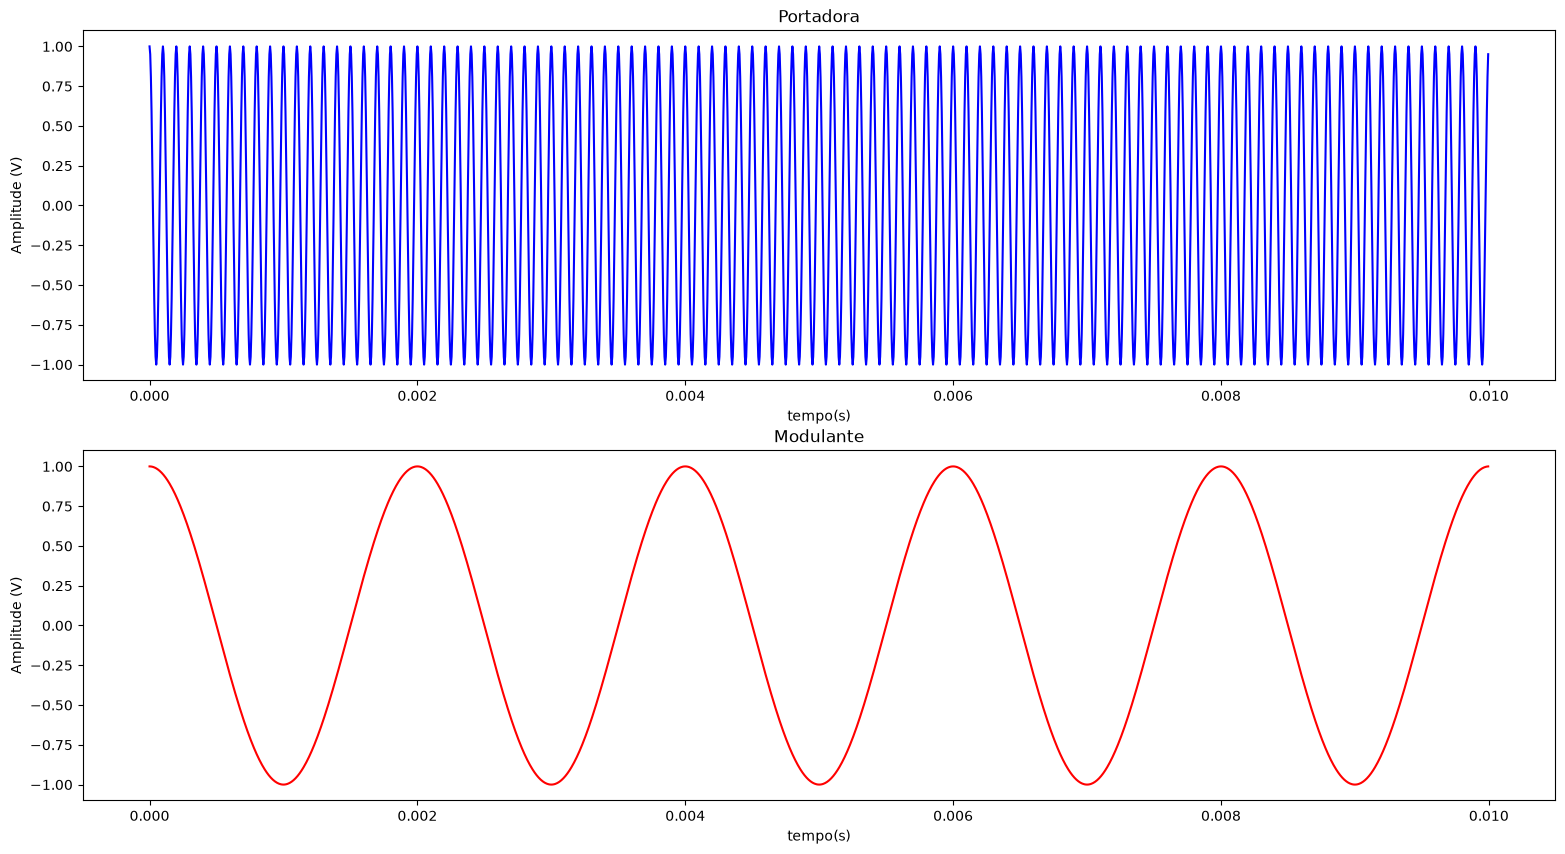

In [4]:
figure, axis = plt.subplots(2, 1) # (linhas, colunas)
plt.subplots_adjust(hspace=0.2) # espaço entre graficos
figure.set_size_inches(19, 10) # tamanho dos graficos

axis[0].plot(t,c,'b')
axis[0].set_title('Portadora')
axis[0].set_ylabel('Amplitude (V)')
axis[0].set_xlabel('tempo(s)')

axis[1].plot(t,m,'r')
axis[1].set_title('Modulante')
axis[1].set_ylabel('Amplitude (V)')
axis[1].set_xlabel('tempo(s)')

EXERCICIO 2 - Modulação AM-DSB (com portadora)

<small>Prompt: como que eu gero s(t) = Ac·[1 + μ·cos(2π·fm·t)]·cos(2π·fc·t) com o am_dsb?

In [5]:
def am_dsb(t, fc, fm, mu, Ac=1.0):
    return Ac * (1 + mu*np.cos(2*np.pi*fm*t)) * np.cos(2*np.pi*fc*t)

def espectro(sinal, fs):
    N = len(sinal)
    S = np.fft.fftshift(np.fft.fft(sinal)) / N
    f = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
    return f, np.abs(S)

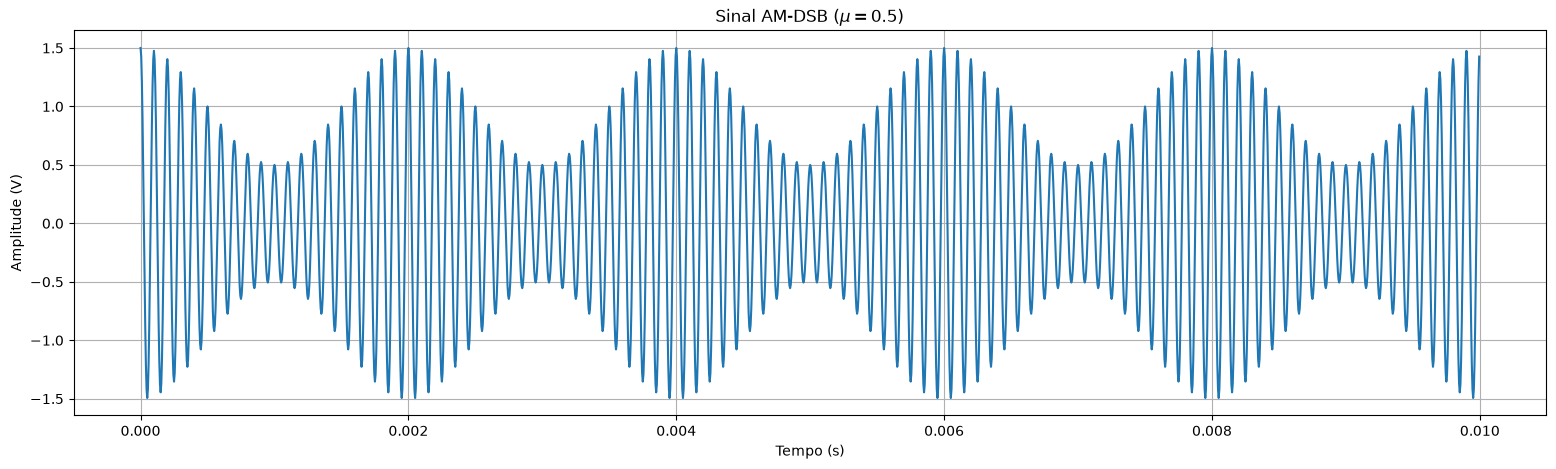

In [6]:
mu = 0.5

s = am_dsb(t, fc, fm, mu, Ac)

plt.figure(figsize=(19, 5))
plt.plot(t, s)
plt.title(f'Sinal AM-DSB ($\\mu={mu}$)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude (V)')
plt.grid()
plt.show()

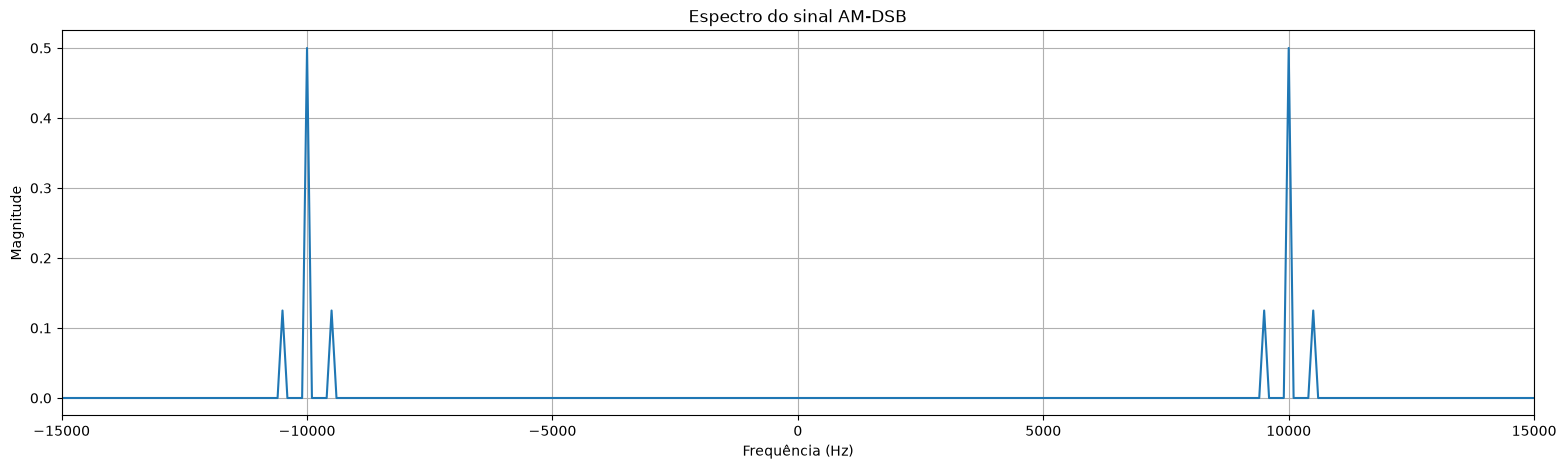

In [7]:
f, S = espectro(s, fs)

plt.figure(figsize=(19, 5))
plt.plot(f, S)
plt.title('Espectro do sinal AM-DSB')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-15000, 15000)
plt.grid()
plt.show()

EXERCICIO 3 - Potência e Eficiência do AM-DSB

<small> [depois do contexto] A primeira coisa que gostaria de fazer é para cada mu gerar um s(t) e estimar numericamente a potencia total (média de s(t)**2) e a potencia da portadora pura, para determinar um eta_medido = 1-(p_p/p_t) para comparar com o eta_teorico</small>

In [8]:
mus = np.arange(0, 2.01, 0.1)
eta_teorico = mus**2 / (2 + mus**2)

In [9]:
potencias_totais = []
potencias_portadora = []
eta_medido = []

In [10]:
# Potência da portadora pura
p_c = np.mean(c**2)

In [11]:
for mu in mus:

    # Gera o sinal AM-DSB
    s = am_dsb(t, fc, fm, mu, Ac)

    # Potência total do sinal modulado
    p_t = np.mean(s**2)

    # Armazena os resultados
    potencias_totais.append(p_t)
    potencias_portadora.append(p_c)

    # Eficiência medida
    eta = 1 - (p_c / p_t)
    eta_medido.append(eta)

In [12]:
# Converte para arrays NumPy
potencias_totais = np.array(potencias_totais)
potencias_portadora = np.array(potencias_portadora)
eta_medido = np.array(eta_medido)

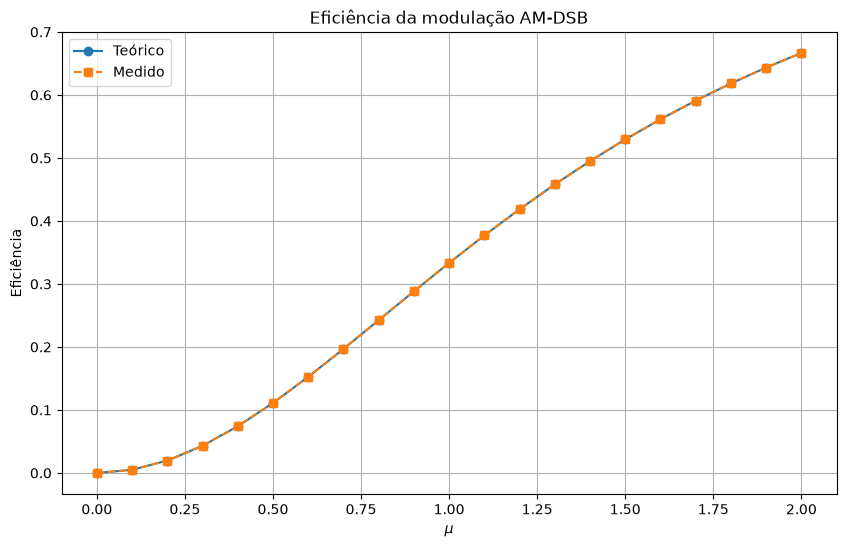

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(mus, eta_teorico, 'o-', label='Teórico')
plt.plot(mus, eta_medido, 's--', label='Medido')

plt.xlabel('$\\mu$')
plt.ylabel('Eficiência')
plt.title('Eficiência da modulação AM-DSB')
plt.grid()
plt.legend()
plt.show()

<small> A melhor Eficiência acontece em u=1, de 33%. Ou seja, péssimo e coerente com o estudado.

EXERCICIO 4 - Demodulação por Detecção de Envoltória

<small> [depois do contexto] primeiro quero criar um s(t) com o am_dsb usando mu=0.7 depois usar a função de detectacao com um fcorte pouco maior que fm e por fim sobrepor o envelope encontrado junto de m(t) original para calcular o erro RMS entre eles.</small>

In [14]:
from scipy.signal import butter, filtfilt

def detector_envoltoria(s, fs, fcorte):
    retificado = np.clip(s, 0, None)   # retificação de meia onda (diodo ideal)
    b, a = butter(2, fcorte/(fs/2), btype='low')
    envelope = filtfilt(b, a, retificado)
    return envelope

In [15]:
mu = 0.7

# Sinal AM-DSB
s = am_dsb(t, fc, fm, mu, Ac)

# Detector de envoltória
fcorte = 2000
envelope = detector_envoltoria(s, fs, fcorte)

# Recupera a modulante
m_detectado = (np.pi * envelope / Ac - 1) / mu

# Erro RMS
erro_rms = np.sqrt(np.mean((m - m_detectado)**2))

print(f"fcorte = {fcorte} Hz")
print(f"Erro RMS = {erro_rms:.6f}")

fcorte = 2000 Hz
Erro RMS = 0.386209


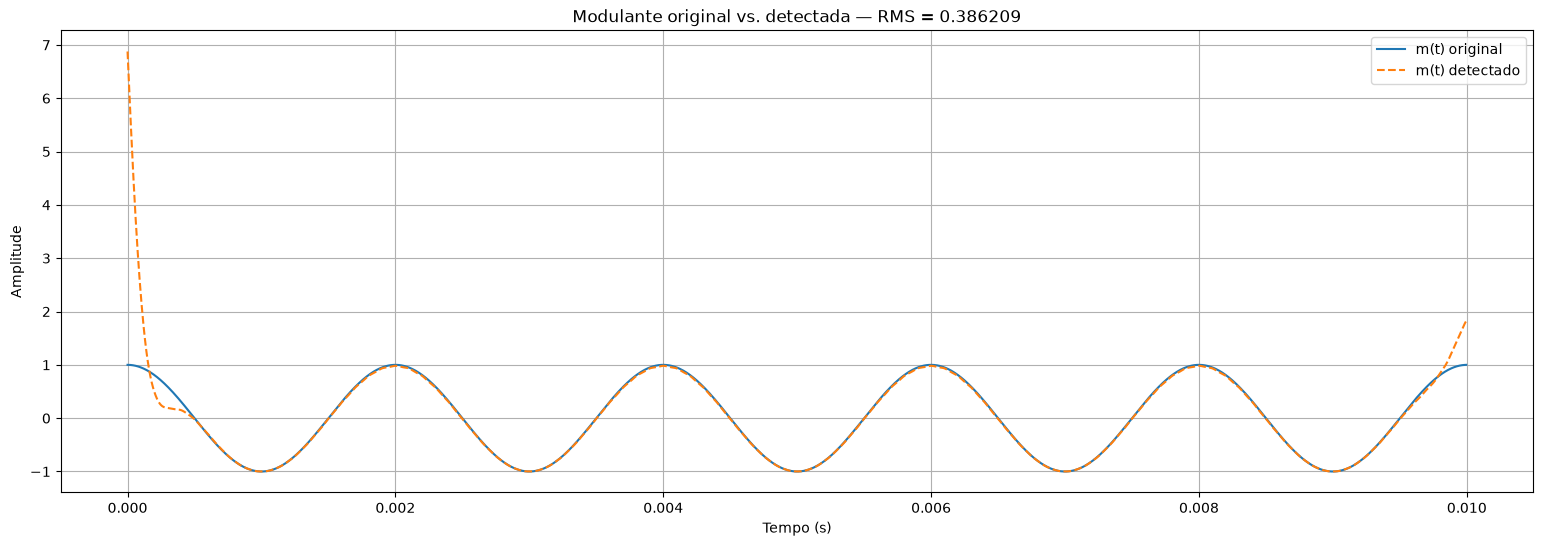

In [16]:
plt.figure(figsize=(19, 6))

plt.plot(t, m, label='m(t) original')
plt.plot(t, m_detectado, '--', label='m(t) detectado')

plt.title(f'Modulante original vs. detectada — RMS = {erro_rms:.6f}')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.show()

EXERCICIO 5 - AM DSB-SC (Portadora Suprimida)

<small> [depois do contexto] e a ideia é agora é gerar um s(t) para comparar com a mesma situação da versão anterior que tem a linha de fc, e depois calcular a potencia total para realizar a comparação com a versão anterior. Para ambos os casos vamos tratar que mu=1</small>

In [17]:
def am_dsb_sc(t, fc, fm, Am=1.0):
    m = Am*np.cos(2*np.pi*fm*t)
    return m * np.cos(2*np.pi*fc*t)

In [18]:
mu = 1.0

# AM-DSB convencional
s_am = am_dsb(t, fc, fm, mu, Ac)

# AM-DSB-SC
s_sc = am_dsb_sc(t, fc, fm, Am)

# Potências médias
p_am = np.mean(s_am**2)
p_sc = np.mean(s_sc**2)

print(f"Potência AM-DSB:    {p_am:.6f}")
print(f"Potência DSB-SC:    {p_sc:.6f}")

Potência AM-DSB:    0.750000
Potência DSB-SC:    0.250000


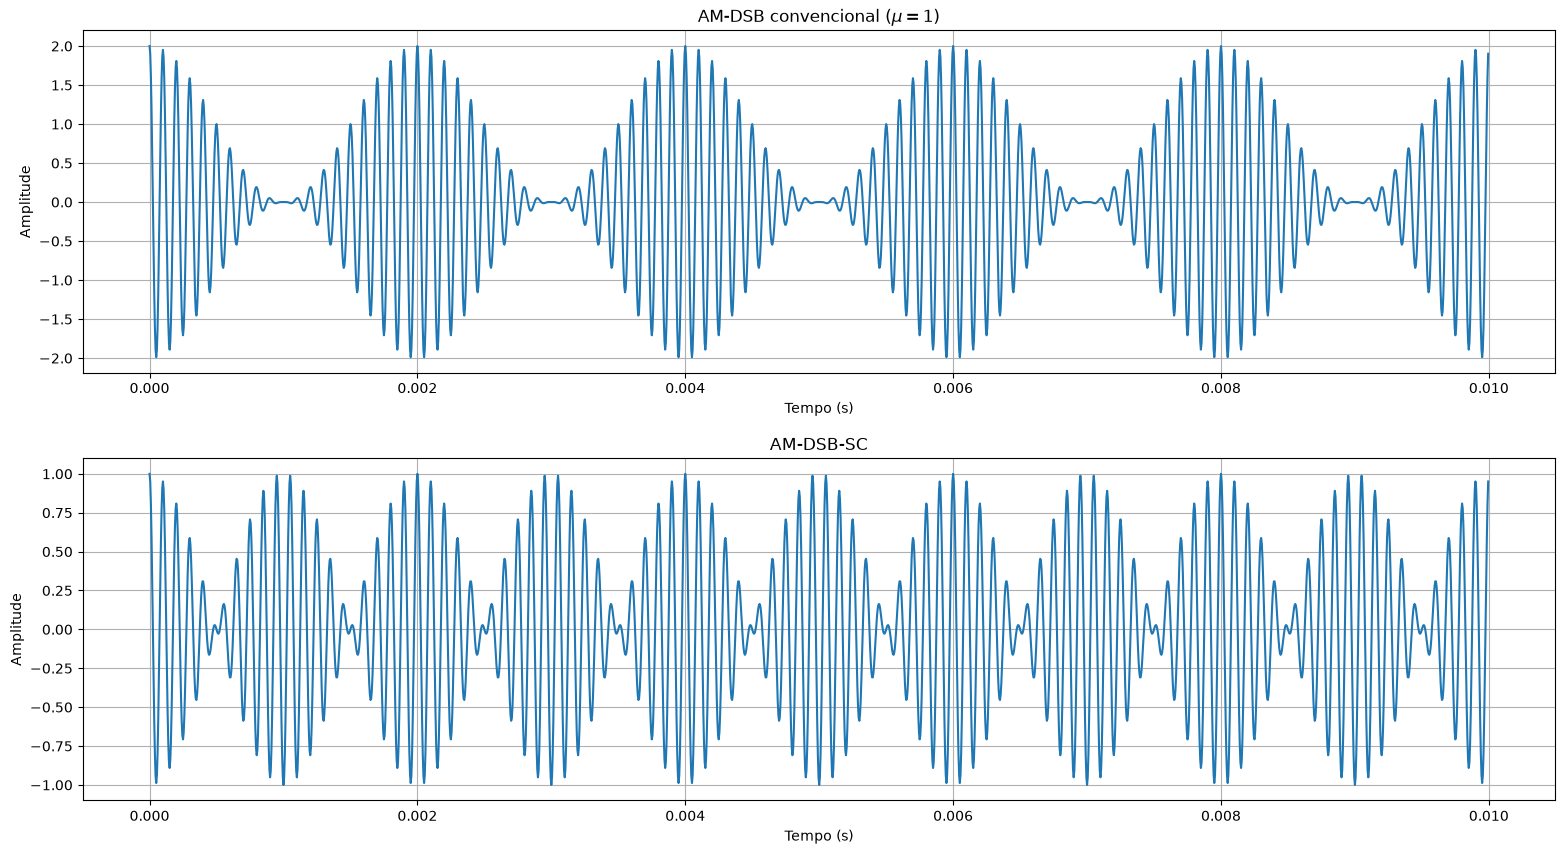

In [19]:
figure, axis = plt.subplots(2, 1)

plt.subplots_adjust(hspace=0.25)
figure.set_size_inches(19, 10)

axis[0].plot(t, s_am)
axis[0].set_title('AM-DSB convencional ($\\mu=1$)')
axis[0].set_ylabel('Amplitude')
axis[0].set_xlabel('Tempo (s)')
axis[0].grid()

axis[1].plot(t, s_sc)
axis[1].set_title('AM-DSB-SC')
axis[1].set_ylabel('Amplitude')
axis[1].set_xlabel('Tempo (s)')
axis[1].grid()

plt.show()

<small> [depois do contexto] se a gente aplicar aquela função detectadora, imagino que não vamos ter um resultado produtivo</small>

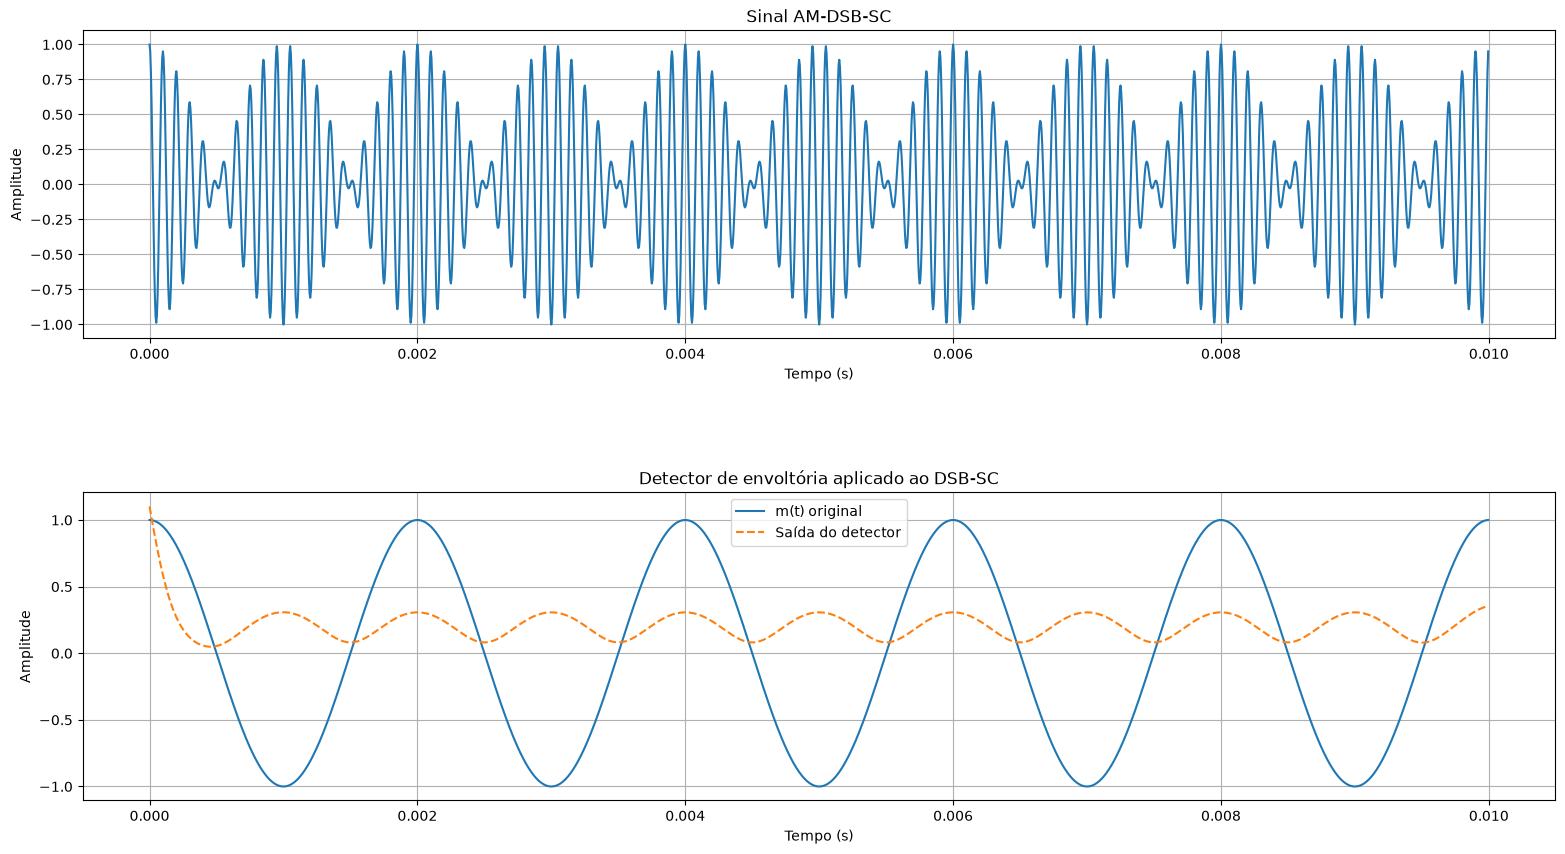

In [20]:
# Aplica o detector de envoltória ao DSB-SC
fcorte = 3 * fm

envelope_sc = detector_envoltoria(s_sc, fs, fcorte)

# Plota o sinal original e o resultado do detector
figure, axis = plt.subplots(2, 1)

plt.subplots_adjust(hspace=0.5)
figure.set_size_inches(19, 10)

axis[0].plot(t, s_sc)
axis[0].set_title('Sinal AM-DSB-SC')
axis[0].set_ylabel('Amplitude')
axis[0].set_xlabel('Tempo (s)')
axis[0].grid()

axis[1].plot(t, m, label='m(t) original')
axis[1].plot(t, envelope_sc, '--', label='Saída do detector')
axis[1].set_title('Detector de envoltória aplicado ao DSB-SC')
axis[1].set_ylabel('Amplitude')
axis[1].set_xlabel('Tempo (s)')
axis[1].legend()
axis[1].grid()

plt.show()

EXERCICIO 6 - Demodulação Síncrona (Detecção Coerente)

<small> [depois do contexto] com ele, como podemos demodolar o sinal anterior?
Depois disso, vamos repetir para phi em pi/6, pi/4, pi/3, pi/2 e verificar como a amplitude muda nesses casos.
Por fim, plotar amplitude_recuperada x phi e sobrepor a curva teórica de cos(phi)</small>

In [21]:
def demod_sincrona(s, t, fc, fs, fcorte, phi=0.0):
    v = s * np.cos(2*np.pi*fc*t + phi)
    b, a = butter(4, fcorte/(fs/2), btype='low')
    return filtfilt(b, a, v)

In [22]:
# DSB-SC
s_sc = am_dsb_sc(t, fc, fm, Am)

# Demodulação síncrona
fcorte = 3 * fm

m_recuperado = demod_sincrona(
    s_sc,
    t,
    fc,
    fs,
    fcorte,
    phi=0.0
)

# Corrige o ganho de 1/2 introduzido pela multiplicação
m_recuperado = 2 * m_recuperado

# Erro RMS
erro_rms = np.sqrt(np.mean((m - m_recuperado)**2))

print(f"Erro RMS = {erro_rms:.6f}")

Erro RMS = 0.099099


In [23]:
phis = np.array([
    np.pi/6,
    np.pi/4,
    np.pi/3,
    np.pi/2
])

amplitudes_recuperadas = []

# Ignora as bordas para evitar os efeitos do filtfilt
mascara = (t > 0.001) & (t < T - 0.001)

for phi in phis:

    m_recuperado = demod_sincrona(
        s_sc,
        t,
        fc,
        fs,
        fcorte,
        phi=phi
    )

    # Corrige o ganho de 1/2 da demodulação
    m_recuperado = 2 * m_recuperado

    # Estima a amplitude através do RMS
    rms = np.sqrt(np.mean(m_recuperado[mascara]**2))
    amplitude = np.sqrt(2) * rms

    amplitudes_recuperadas.append(amplitude)

amplitudes_recuperadas = np.array(amplitudes_recuperadas)

In [24]:
amplitudes_teoricas = Am * np.abs(np.cos(phis))

In [25]:
for phi, medido, teorico in zip(
    phis,
    amplitudes_recuperadas,
    amplitudes_teoricas
):
    print(
        f"φ = {phi:.4f} rad "
        f"({np.degrees(phi):.1f}°) | "
        f"Medido = {medido:.6f} | "
        f"Teórico = {teorico:.6f}"
    )

φ = 0.5236 rad (30.0°) | Medido = 0.865906 | Teórico = 0.866025
φ = 0.7854 rad (45.0°) | Medido = 0.707013 | Teórico = 0.707107
φ = 1.0472 rad (60.0°) | Medido = 0.499938 | Teórico = 0.500000
φ = 1.5708 rad (90.0°) | Medido = 0.000054 | Teórico = 0.000000


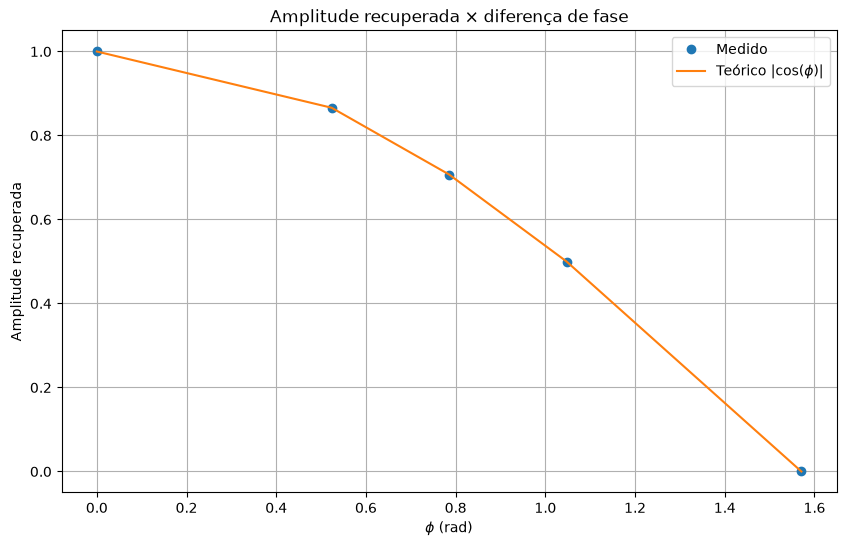

In [26]:
phis_plot = np.concatenate(([0], phis))

amplitudes_plot = np.concatenate((
    [Am],
    amplitudes_recuperadas
))

amplitudes_teoricas_plot = Am * np.abs(np.cos(phis_plot))

plt.figure(figsize=(10, 6))

plt.plot(
    phis_plot,
    amplitudes_plot,
    'o',
    label='Medido'
)

plt.plot(
    phis_plot,
    amplitudes_teoricas_plot,
    '-',
    label='Teórico $|\\cos(\\phi)|$'
)

plt.xlabel('$\\phi$ (rad)')
plt.ylabel('Amplitude recuperada')
plt.title('Amplitude recuperada × diferença de fase')
plt.grid()
plt.legend()

plt.show()

<small> A amplitude reduz conforme o ângulo aumenta, a passo de que se pode perder o sinal praticamente por completo.</small>

EXERCICIO 7 - AM-SSB (Banda Lateral Única)

<small> [depois do contexto] A ideia é gerar s(t) para USB e LSB e verificar usando um plot que os dois apresentam somente uma banda lateral.
Depois disso, medir a largura de banda e comparar com a largura da situação de AM-DSB feita anteriormente. Em teoria deve ser uma razão proxima de 2</small>

In [27]:
from scipy.signal import hilbert

def am_ssb(t, fc, fm, banda='USB', Am=1.0):
    m = Am*np.cos(2*np.pi*fm*t)
    m_hat = np.imag(hilbert(m))   # transformada de Hilbert de m(t)
    sinal_sign = -1 if banda == 'USB' else +1
    return m*np.cos(2*np.pi*fc*t) + sinal_sign*m_hat*np.sin(2*np.pi*fc*t)

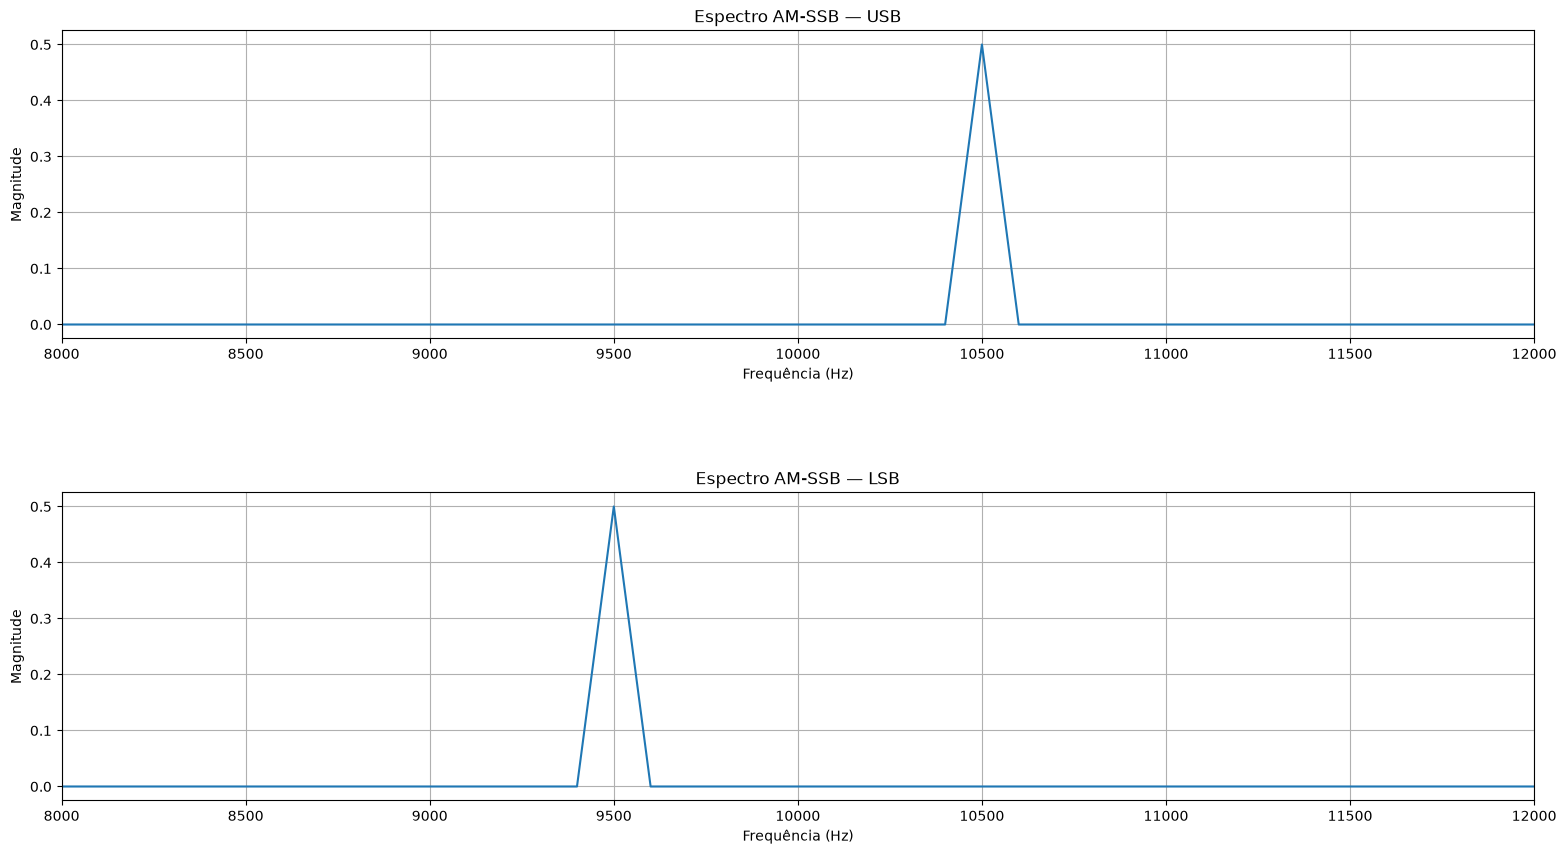

In [28]:
# Gera os sinais SSB
s_usb = am_ssb(t, fc, fm, banda='USB', Am=Am)
s_lsb = am_ssb(t, fc, fm, banda='LSB', Am=Am)

# Calcula os espectros
f_usb, S_usb = espectro(s_usb, fs)
f_lsb, S_lsb = espectro(s_lsb, fs)

# Plot
figure, axis = plt.subplots(2, 1)

plt.subplots_adjust(hspace=0.5)
figure.set_size_inches(19, 10)

axis[0].plot(f_usb, S_usb)
axis[0].set_title('Espectro AM-SSB — USB')
axis[0].set_xlabel('Frequência (Hz)')
axis[0].set_ylabel('Magnitude')
axis[0].set_xlim(8000, 12000)
axis[0].grid()

axis[1].plot(f_lsb, S_lsb)
axis[1].set_title('Espectro AM-SSB — LSB')
axis[1].set_xlabel('Frequência (Hz)')
axis[1].set_ylabel('Magnitude')
axis[1].set_xlim(8000, 12000)
axis[1].grid()

plt.show()

In [29]:
bw_dsb = 2 * fm
bw_ssb = fm

razao_bw = bw_dsb / bw_ssb

print(f"BW AM-DSB = {bw_dsb:.0f} Hz")
print(f"BW AM-SSB = {bw_ssb:.0f} Hz")
print(f"Razão BW_DSB / BW_SSB = {razao_bw:.2f}")

BW AM-DSB = 1000 Hz
BW AM-SSB = 500 Hz
Razão BW_DSB / BW_SSB = 2.00


ATIVIDADE DESAFIO - AM-DSB com Áudio Real

<small> [depois de contexto] eu devo usar um fc pelo menos 5x maior que a maior frequencia presente no áudio, mas eu não entendi como eu faço isso. Também gerar um vetor de tempo t compatível com fs_audio e len(m)</small>

In [30]:
from scipy.io import wavfile
from scipy.signal import resample_poly

# =========================
# Carrega o áudio
# =========================

fs_audio, audio = wavfile.read('teste.wav')

# Se for estéreo, converte para mono
if audio.ndim == 2:
    audio = np.mean(audio, axis=1)

# Converte para float
m = audio.astype(np.float64)

# Normaliza para [-1, 1]
m = m / np.max(np.abs(m))


# =========================
# Resampling
# =========================

fs = 200_000

# 44.1 kHz -> 200 kHz
m = resample_poly(m, 2000, 441)

# Normaliza novamente após o resampling
m = m / np.max(np.abs(m))


# =========================
# Vetor de tempo
# =========================

t = np.arange(len(m)) / fs


# =========================
# Frequência máxima e portadora
# =========================

f_max = 5_000
fc = 5 * f_max


# =========================
# Informações
# =========================

print(f"Fs original:       {fs_audio} Hz")
print(f"Fs de trabalho:    {fs} Hz")
print(f"Duração:            {len(m)/fs:.3f} s")
print(f"f_max considerada:  {f_max} Hz")
print(f"fc:                 {fc} Hz")
print(f"Nyquist:            {fs/2} Hz")

Fs original:       44100 Hz
Fs de trabalho:    200000 Hz
Duração:            4.706 s
f_max considerada:  5000 Hz
fc:                 25000 Hz
Nyquist:            100000.0 Hz


In [31]:
def am_dsb(t, fc, fm=None, mu=1.0, Ac=1.0):
    if fm is None:
        modulante = m
    else:
        modulante = np.cos(2*np.pi*fm*t)

    return Ac * (1 + mu * modulante) * np.cos(2*np.pi*fc*t)

In [32]:
f_max = 5000
fc = 25000
fs = 200000

In [33]:
fcorte = 1.5 * f_max

<small> Agora é gerar o am-dsb do áudio para vários indices. indices = [0.3, 0.7, 1.0, 1.5, 2.0] com aquela função am_dsb(t, fc, fm=None, mu, Ac=1.0) que já estavamos usando. depois demodular com o detectador_envolotoria já usado, remover o nivel DC eo envelope encontrado, e então salvar o resultado com um wavfile.write para verificar o resultado</small>

In [34]:
from scipy.io import wavfile

indices = [0.3, 0.7, 1.0, 1.5, 2.0]

fcorte = 3 * f_max

for mu in indices:

    # =========================
    # Modulação AM-DSB
    # =========================

    s = am_dsb(t, fc, None, mu)


    # =========================
    # Detector de envoltória
    # =========================

    envelope = detector_envoltoria(s, fs, fcorte)


    # =========================
    # Remove DC e corrige ganho
    # =========================

    # Para a retificação de meia onda:
    #
    # envelope ≈ Ac/pi * (1 + mu*m)
    #
    # Portanto:
    #
    # m_rec = (pi*envelope/Ac - 1)/mu

    m_recuperado = (np.pi * envelope / 1.0 - 1) / mu


    # =========================
    # Normaliza para WAV
    # =========================

    m_recuperado = m_recuperado / np.max(np.abs(m_recuperado))

    # Converte para int16
    audio_saida = np.int16(
        np.clip(m_recuperado, -1, 1) * 32767
    )


    # =========================
    # Salva
    # =========================

    nome = f"audio_am_mu_{mu:.1f}.wav"

    wavfile.write(
        nome,
        fs,
        audio_saida
    )

    print(f"μ = {mu:.1f} -> {nome}")

μ = 0.3 -> audio_am_mu_0.3.wav
μ = 0.7 -> audio_am_mu_0.7.wav
μ = 1.0 -> audio_am_mu_1.0.wav
μ = 1.5 -> audio_am_mu_1.5.wav
μ = 2.0 -> audio_am_mu_2.0.wav


<small> agora eu tenho que plotar o áudio recuperado para os casos de u<=1 sobre o original

nos casos onde u>1, plotar a envoltória do sinal modulado com o m(t) original para verificar inversões de fase</small>

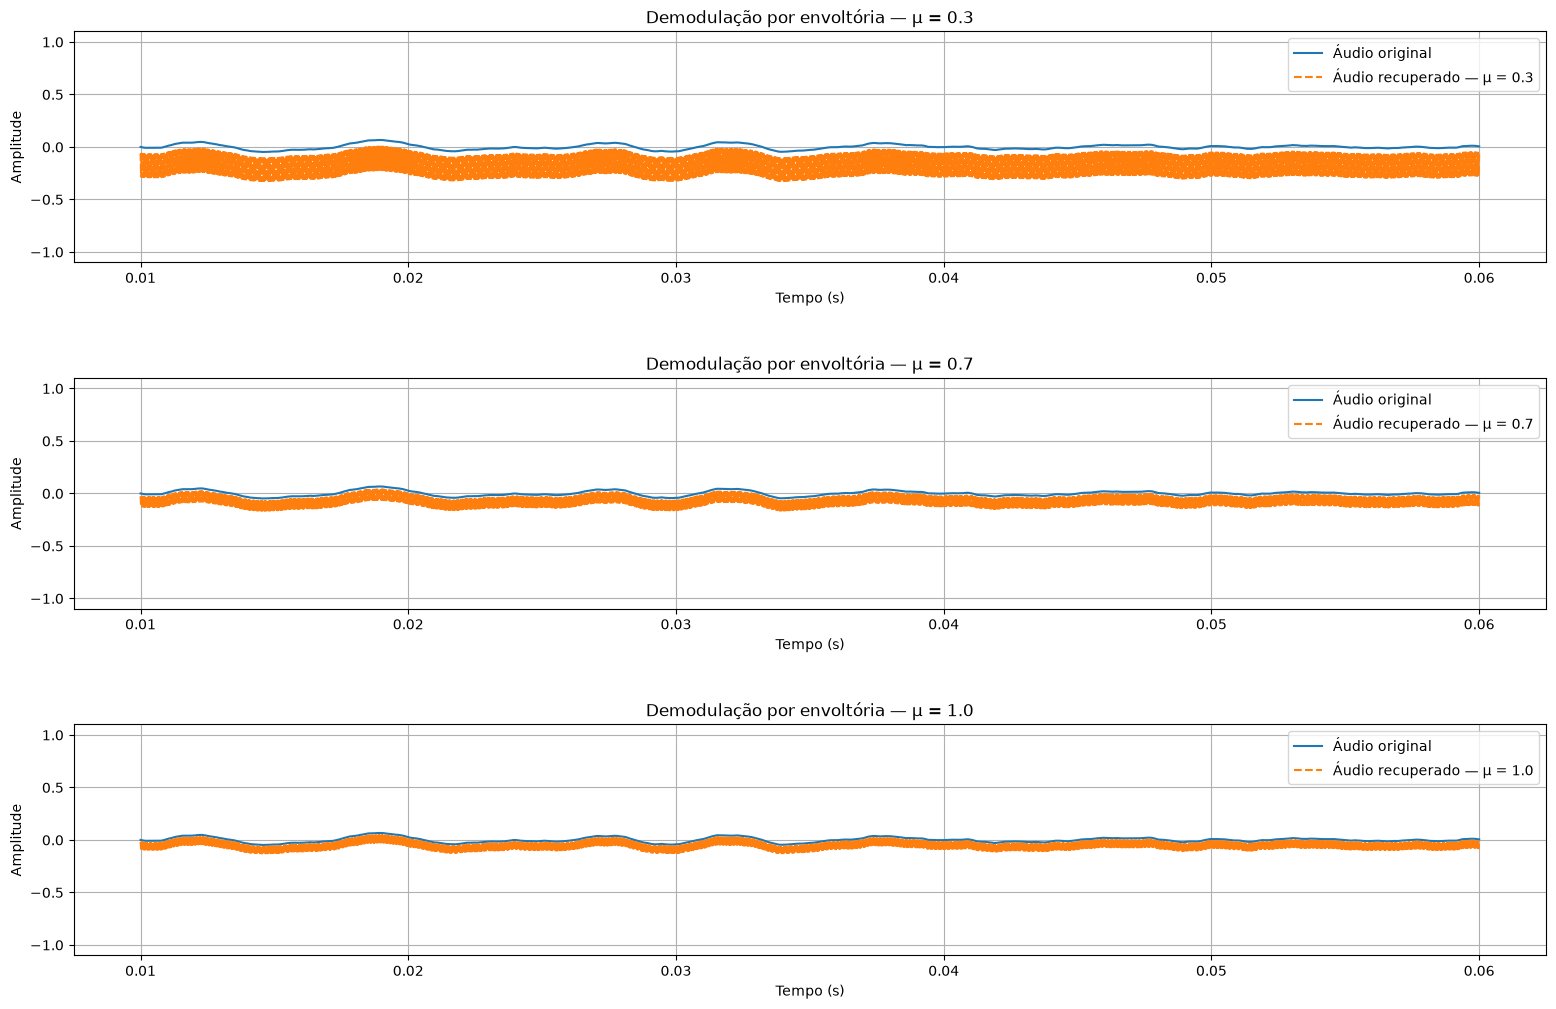

In [35]:
from scipy.io import wavfile

indices_sem_sobremod = [0.3, 0.7, 1.0]

fcorte = 2 * f_max

# Janela de visualização: 10 ms até 60 ms
janela = (t >= 0.01) & (t <= 0.06)

figure, axis = plt.subplots(3, 1)

plt.subplots_adjust(hspace=0.5)
figure.set_size_inches(19, 12)

for ax, mu in zip(axis, indices_sem_sobremod):

    # =========================
    # Gera o AM-DSB
    # =========================

    s = am_dsb(t, fc, None, mu)

    # =========================
    # Detector de envoltória
    # =========================

    envelope = detector_envoltoria(s, fs, fcorte)

    # =========================
    # Remove DC e recupera áudio
    # =========================

    audio_recuperado = (np.pi * envelope - 1) / mu

    # =========================
    # Plot
    # =========================

    ax.plot(
        t[janela],
        m[janela],
        label='Áudio original'
    )

    ax.plot(
        t[janela],
        audio_recuperado[janela],
        '--',
        label=f'Áudio recuperado — μ = {mu}'
    )

    ax.set_ylim(-1.1, 1.1)
    ax.set_title(f'Demodulação por envoltória — μ = {mu}')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')
    ax.grid()
    ax.legend()

plt.show()

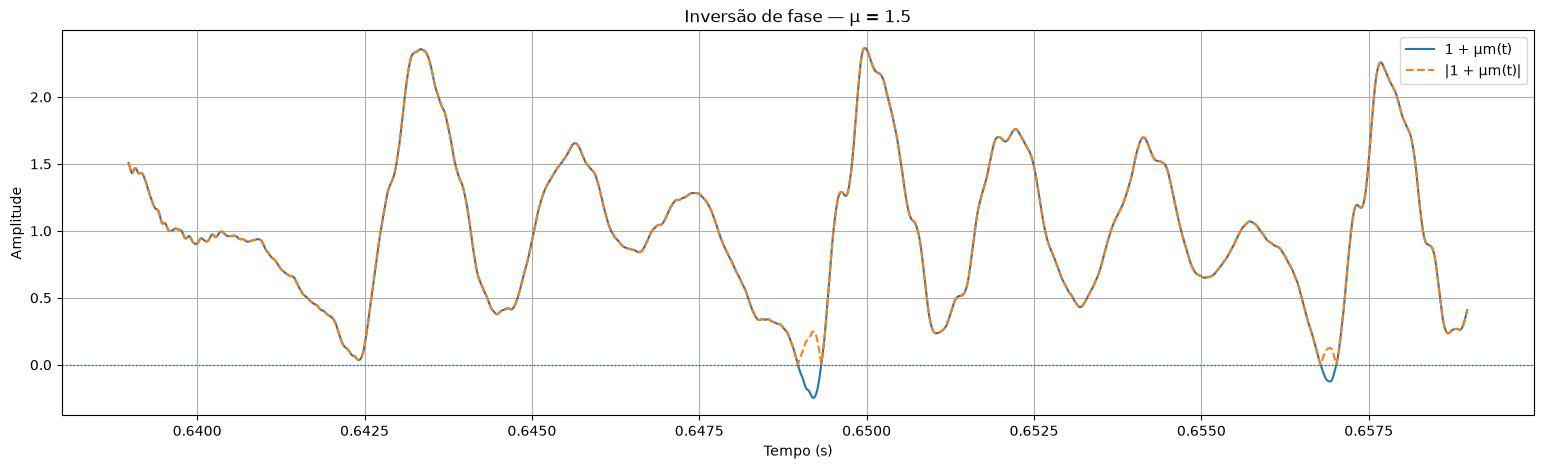

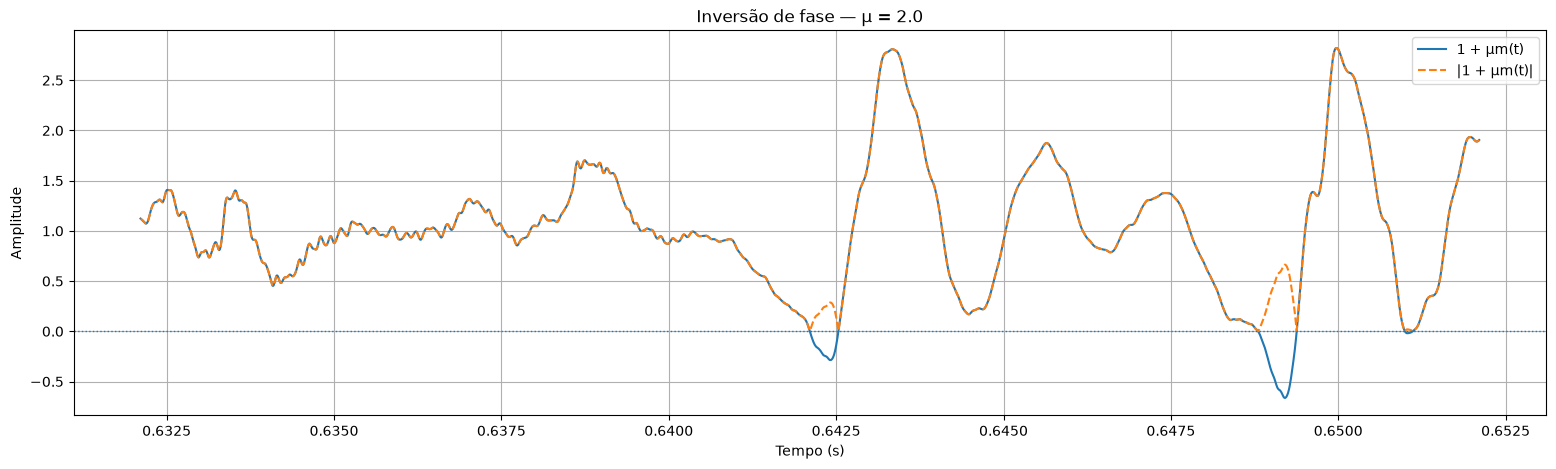

In [36]:
indices_sobremod = [1.5, 2.0]

for mu in indices_sobremod:

    # Envoltória teórica assinada
    envoltoria_assinada = 1 + mu * m

    # Envoltória física
    envoltoria_fisica = np.abs(envoltoria_assinada)

    # Procura região onde existe sobremodulação
    idx = np.where(envoltoria_assinada < 0)[0]

    if len(idx) == 0:
        print(f"μ = {mu}: não há sobremodulação no áudio.")
        continue

    # Pega uma região ao redor da primeira ocorrência
    i = idx[0]

    inicio = max(0, i - 2000)
    fim = min(len(t), i + 2000)

    plt.figure(figsize=(19, 5))

    plt.plot(
        t[inicio:fim],
        envoltoria_assinada[inicio:fim],
        label='1 + μm(t)'
    )

    plt.plot(
        t[inicio:fim],
        envoltoria_fisica[inicio:fim],
        '--',
        label='|1 + μm(t)|'
    )

    plt.axhline(
        0,
        linestyle=':',
        linewidth=1
    )

    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.title(f'Inversão de fase — μ = {mu}')
    plt.grid()
    plt.legend()

    plt.show()

<small> Curiosamente, com o áudio que eu utilizei os pontos onde ocorre inversões nos casos de u=1,5 e u=2 são somente dois, além de serem relativamente pequenos quando comparados com o restante do áudio. Isso é coerente com o áudio escutado, que em relação aos casos de u<=0 simplesmente parecem mais altos.</small>

In [37]:
# AM-DSB convencional
mu = 1.0

s_dsb = am_dsb(t, fc, fm, mu)

p_total_dsb = np.mean(s_dsb**2)
p_portadora = np.mean(c**2)

eta_dsb = 1 - p_portadora / p_total_dsb


# DSB-SC
s_dsb_sc = am_dsb_sc(t, fc, fm)

p_total_dsb_sc = np.mean(s_dsb_sc**2)

# Não existe portadora no DSB-SC
p_portadora_dsb_sc = 0

eta_dsb_sc = 1 - p_portadora_dsb_sc / p_total_dsb_sc


print(f"AM-DSB:   η = {eta_dsb*100:.2f}%")
print(f"DSB-SC:   η = {eta_dsb_sc*100:.2f}%")

AM-DSB:   η = 33.33%
DSB-SC:   η = 100.00%


Qual variante de AM apresentou a maior eficiência de potência na sua simulação, e isso bate com o previsto pela teoria?

<small> Na simulação, a variante com maior eficiência de potência foi o AM-DSB-SC, atingindo 100%. Esse resultado está de acordo com a teoria, pois a portadora é suprimida e, consequentemente, a potência transmitida fica concentrada nas bandas laterais, que contêm a informação.</small>

Qual variante exigiu o receptor mais complexo para demodular corretamente? Justifique com base no que você implementou (envoltória vs. síncrona).

<small> A variante que exigiu o receptor mais complexo foi o AM-DSB-SC (portadora suprimida).
 
 No AM-DSB convencional, foi possível utilizar um detector de envoltória, composto por uma etapa de retificação seguida de um filtro passa-baixas. Como a portadora está presente no sinal, a informação da modulante pode ser recuperada a partir da envoltória, que faz de forma simplificada:

$$
s(t)
\rightarrow
\text{retificação}
\rightarrow
\text{filtro passa-baixas}
\rightarrow
\text{envoltória recuperada}.
$$

O  AM-DSB-SC exige uma portadora local sincronizada em frequência e fase, tornando o receptor mais complexo.</small>

Considerando potência, largura de banda e complexidade de receptor juntos, qual variante você recomendaria para um sistema de comunicação de baixo custo, e qual para um sistema com espectro escasso e caro? Justifique.

<small> Para o caso de baixo custo, provavelmente o AM-DSB convencional. Mesmo que a eficiência seja baixa, o receptor pode ser bem simples, o que reduz bastante o custo.

Para um sistema que o espectro é escasso e caro, o AM-SSB seria a melhor opção. Já que só uma das bandas laterais é transmitida, isso reduz significativamente a largura de banda necessária por quase metade em relação ao AM-DSB.

$$
B_{\mathrm{DSB}} = 2B_m
$$

enquanto:

$$
B_{\mathrm{SSB}} = B_m
$$

Além disso, a portadora pode ser suprimida, diminuindo o desperdício de potência. Logo, o SSB apresenta uma utilização mais eficiente tanto do espectro quanto da potência.

O maior problema dessa abordagem seria a complexidade do receptor.</small>

Na Atividade Desafio, o que aconteceu com o áudio recuperado quando μ > 1? Isso confirma qual limite teórico visto em aula?

<small> Apresentou algumas distorções. O que batem com o notado em sala de aula.

Para $\mu=1$, a envoltória pode chegar a zero, mas não muda de sinal.
Para $\mu>1$, ocorre sobremodulação e a recuperação por detector de
envoltória deixa de ser correta.</small>